# 02. Modelado Predictivo Avanzado (Enfoque Academico)

## 1. Introduccion
En esta segunda fase, utilizamos los datos enriquecidos para entrenar un modelo de **Gradient Boosting (XGBoost)** capaz de predecir la probabilidad de los resultados (1X2).

### Estrategia de Modelado:
1. **Validacion Temporal (TimeSeriesSplit)**: Al ser datos de series temporales, no podemos usar un train_test_split aleatorio (causaria data leakage). Usamos una ventana deslizante.
2. **Optimizacion Bayesiana (Optuna)**: Para encontrar los hiperparametros optimos del modelo de forma eficiente.
3. **Metrica de Evaluacion (Log Loss)**: Priorizamos la calibracion de las probabilidades sobre la precision pura.

In [68]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import log_loss, accuracy_score, confusion_matrix
from sklearn.model_selection import TimeSeriesSplit
import joblib
import optuna
import os

optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.style.use("ggplot")
sns.set_palette("husl")

print("Librerias de ML cargadas.")

Librerias de ML cargadas.


## 2. Carga del Dataset Enriquecido
Cargamos el archivo `df_final_features.csv`. El script busca automaticamente en varias rutas.

In [69]:
import json
import difflib
import numpy as np

print(f"Directorio de trabajo actual: {os.getcwd()}")

possible_paths = [
    "../df_final_app.csv",
    "LaLiga/df_final_app.csv",
    "df_final_app.csv",
    "../../df_final_app.csv",
    "../../LaLiga/df_final_app.csv"
]

CSV_PATH = None
for p in possible_paths:
    if os.path.exists(p):
        CSV_PATH = p
        print(f"Archivo encontrado en: {p}")
        break

if not CSV_PATH:
    raise FileNotFoundError(f"df_final_app.csv no encontrado. Se busco en: {possible_paths}")

df = pd.read_csv(CSV_PATH)
df["Date"] = pd.to_datetime(df["Date"])

# DEDUPLICACION CRITICA (Fix preventivo para Season 2024)
before = len(df)
df = df.drop_duplicates(subset=['Date', 'HomeTeam', 'AwayTeam'], keep='first').reset_index(drop=True)
if len(df) != before:
    print(f"⚠️ Se eliminaron {before - len(df)} filas duplicadas en la carga inicial.")

target_map = {"A": 0, "D": 1, "H": 2}
df["Target"] = df["FTR"].map(target_map)

# ===========================================================
# ENRIQUECIMIENTO: FIFA & TRANSFERMARKT
# ===========================================================
SOFIFA_PATH = "../data/sofifa_history.json"
TM_PATH = "../data/transfermarkt_history.json"

# Check local paths if running from notebooks dir
if not os.path.exists(SOFIFA_PATH): SOFIFA_PATH = "../../data/sofifa_history.json"
if not os.path.exists(SOFIFA_PATH): SOFIFA_PATH = "data/sofifa_history.json"

if not os.path.exists(TM_PATH): TM_PATH = "../../data/transfermarkt_history.json"
if not os.path.exists(TM_PATH): TM_PATH = "data/transfermarkt_history.json"

if os.path.exists(SOFIFA_PATH) and os.path.exists(TM_PATH):
    print("Cargando datos externos (FIFA + Transfermarkt)...")
    with open(SOFIFA_PATH, 'r', encoding='utf-8') as f: sofifa_data = json.load(f)
    with open(TM_PATH, 'r', encoding='utf-8') as f: tm_data = json.load(f)
    
    # Helper: Normalizar Valor de Mercado
    def parse_tm_value(val_str):
        if not isinstance(val_str, str): return 0.0
        val_str = val_str.replace('€', '')
        if 'bn' in val_str: return float(val_str.replace('bn', '')) * 1000
        elif 'm' in val_str: return float(val_str.replace('m', ''))
        elif 'Th' in val_str: return float(val_str.replace('Th.', '')) / 1000
        return 0.0

    # Helper: Match Fuzzy
    def get_match(name, candidates):
        match = difflib.get_close_matches(name, candidates, n=1, cutoff=0.5)
        return match[0] if match else None

    # Inicializar columnas con NaN
    new_cols = [
        'Home_FIFA_OVR', 'Home_FIFA_ATT', 'Home_FIFA_MID', 'Home_FIFA_DEF',
        'Away_FIFA_OVR', 'Away_FIFA_ATT', 'Away_FIFA_MID', 'Away_FIFA_DEF',
        'Home_TM_Value', 'Home_TM_Avg_Age',
        'Away_TM_Value', 'Away_TM_Avg_Age'
    ]
    for c in new_cols: df[c] = np.nan

    # Iterar por temporada para mapeo preciso
    for season in df['Season'].unique():
        s_str = str(season)
        season_teams = df[df['Season'] == season]['HomeTeam'].unique()
        
        # --- PROCESAR FIFA ---
        if s_str in sofifa_data:
            fifa_recs = {t['team']: t for t in sofifa_data[s_str]}
            fifa_names = list(fifa_recs.keys())
            
            for team in season_teams:
                match = get_match(team, fifa_names)
                if match:
                    data = fifa_recs[match]
                    # Asignar a HomeTeam
                    mask_h = (df['Season'] == season) & (df['HomeTeam'] == team)
                    df.loc[mask_h, 'Home_FIFA_OVR'] = float(data.get('ova', 0))
                    df.loc[mask_h, 'Home_FIFA_ATT'] = float(data.get('att', 0))
                    df.loc[mask_h, 'Home_FIFA_MID'] = float(data.get('mid', 0))
                    df.loc[mask_h, 'Home_FIFA_DEF'] = float(data.get('def', 0))
                    # Asignar a AwayTeam
                    mask_a = (df['Season'] == season) & (df['AwayTeam'] == team)
                    df.loc[mask_a, 'Away_FIFA_OVR'] = float(data.get('ova', 0))
                    df.loc[mask_a, 'Away_FIFA_ATT'] = float(data.get('att', 0))
                    df.loc[mask_a, 'Away_FIFA_MID'] = float(data.get('mid', 0))
                    df.loc[mask_a, 'Away_FIFA_DEF'] = float(data.get('def', 0))

        # --- PROCESAR TRANSFERMARKT ---
        if s_str in tm_data:
            tm_recs = {t['team']: t for t in tm_data[s_str]}
            tm_names = list(tm_recs.keys())
            
            for team in season_teams:
                match = get_match(team, tm_names)
                if match:
                    data = tm_recs[match]
                    val = parse_tm_value(data.get('value', '0'))
                    age = float(data.get('avg_age', 0) or 0)
                    
                    mask_h = (df['Season'] == season) & (df['HomeTeam'] == team)
                    df.loc[mask_h, 'Home_TM_Value'] = val
                    df.loc[mask_h, 'Home_TM_Avg_Age'] = age
                    
                    mask_a = (df['Season'] == season) & (df['AwayTeam'] == team)
                    df.loc[mask_a, 'Away_TM_Value'] = val
                    df.loc[mask_a, 'Away_TM_Avg_Age'] = age

    # Imputar faltantes (Media o Forward Fill)
    df = df.fillna(method='ffill').fillna(method='bfill')
    print("Datos FIFA y Transfermarkt fusionados correctamente.")

else:
    print("⚠️ NO SE ENCONTRARON JSONs de FIFA/TM. Se omiten estas features.")

# Features actualizadas para el Modelo
features = [
    "Home_Elo", "Away_Elo",
    "Home_xG_Avg_L5", "Away_xG_Avg_L5",
    "Home_Streak_L5", "Away_Streak_L5",
    "Home_Pressure_Avg_L5", "Away_Pressure_Avg_L5",
    "Home_Dominance_Avg_L5", "Away_Dominance_Avg_L5",
    # Nuevas Features
    "Home_FIFA_OVR", "Away_FIFA_OVR",
    "Home_TM_Value", "Away_TM_Value",
    "Home_TM_Avg_Age", "Away_TM_Avg_Age"
]

print(f"Datos Totales (Post-Procesamiento): {len(df)} registros.")
df.head()

Directorio de trabajo actual: c:\Users\emili\OneDrive\Escritorio\US SEVILLA\winamax-odds-detector\TFG_REPOSITORIO\LaLiga\notebooks
Archivo encontrado en: ../df_final_app.csv
⚠️ Se eliminaron 2660 filas duplicadas en la carga inicial.
Cargando datos externos (FIFA + Transfermarkt)...
Datos FIFA y Transfermarkt fusionados correctamente.
Datos Totales (Post-Procesamiento): 5700 registros.


C:\Users\emili\AppData\Local\Temp\ipykernel_6524\1472776679.py:126: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill')


,Date,Season,HomeTeam,AwayTeam,FTR,Home_Elo,Away_Elo,Home_xG_Proxy,Away_xG_Proxy,Home_xG_Avg_L5,...,Home_FIFA_MID,Home_FIFA_DEF,Away_FIFA_OVR,Away_FIFA_ATT,Away_FIFA_MID,Away_FIFA_DEF,Home_TM_Value,Home_TM_Avg_Age,Away_TM_Value,Away_TM_Avg_Age
0,2010-08-28,2010,Hercules,Athletic Club,A,1500.0,1500.0,1.68,2.71,0.0,...,73.0,71.0,75.0,66.0,70.0,70.0,51.70,0.0,112.0,0.0
1,2010-08-28,2010,Levante UD,Sevilla FC,A,1500.0,1500.0,1.79,3.58,0.0,...,73.0,71.0,79.0,71.0,78.0,71.0,37.40,0.0,175.6,0.0
2,2010-08-28,2010,Malaga,Valencia CF,A,1500.0,1500.0,3.16,4.21,0.0,...,73.0,71.0,80.0,73.0,76.0,75.0,71.05,0.0,176.6,0.0
3,2010-08-29,2010,RCD Espanyol,Getafe CF,H,1500.0,1500.0,3.85,1.46,0.0,...,67.0,67.0,75.0,72.0,72.0,75.0,78.40,0.0,66.4,0.0
4,2010-08-29,2010,La Coruna,Zaragoza,D,1500.0,1500.0,1.30,1.59,0.0,...,67.0,67.0,75.0,72.0,72.0,75.0,63.70,0.0,57.0,0.0


## 3. Division Entrenamiento / Test (Respetando el Tiempo)
Separamos la ultima temporada completa como **Test Set** para simular prediccion Out-of-Sample.

In [70]:
TEST_SEASON_START = 2024

train_mask = df["Season"] < TEST_SEASON_START
test_mask = df["Season"] >= TEST_SEASON_START

X_train = df.loc[train_mask, features].astype(float)
y_train = df.loc[train_mask, "Target"].astype(int)
X_test = df.loc[test_mask, features].astype(float)
y_test = df.loc[test_mask, "Target"].astype(int)

print(f"Entrenamiento: {len(X_train)} partidos")
print(f"Test (Validacion): {len(X_test)} partidos")

Entrenamiento: 5320 partidos
Test (Validacion): 380 partidos


## 4. Optimizacion de Hiperparametros con Optuna

XGBoost tiene muchos parametros (learning_rate, max_depth, subsample). Ajustarlos a mano es ineficiente.

Usamos **Optuna**, un framework de optimizacion bayesiana, para buscar la mejor combinacion que minimice el **Log Loss** en validacion cruzada temporal.

In [71]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "objective": "multi:softprob",
        "num_class": 3,
        "random_state": 42,
        "n_jobs": -1,
        "verbosity": 0
    }
    
    # Walk-Forward por Temporadas (Rolling Window 5 Seasons)
    seasons_opt = sorted(df['Season'].unique())
    window_size = 5
    scores = []
    
    for i in range(len(seasons_opt) - window_size):
        train_seasons = seasons_opt[i : i + window_size]
        test_season  = seasons_opt[i + window_size]
        
        train_mask = df['Season'].isin(train_seasons)
        test_mask  = df['Season'] == test_season
        
        X_t = df.loc[train_mask, features].astype(float)
        y_t = df.loc[train_mask, 'Target'].astype(int)
        X_v = df.loc[test_mask,  features].astype(float)
        y_v = df.loc[test_mask,  'Target'].astype(int)
        
        model = xgb.XGBClassifier(**params)
        model.fit(X_t, y_t, verbose=False)
        preds = model.predict_proba(X_v)
        score = log_loss(y_v, preds)
        scores.append(score)
    
    return np.mean(scores)

print("Iniciando estudio de Optuna (10 trials)...")
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=10)

print(f"Mejores parametros: {study.best_params}")
print(f"Mejor LogLoss CV: {study.best_value:.4f}")

Iniciando estudio de Optuna (10 trials)...
Mejores parametros: {'n_estimators': 535, 'learning_rate': 0.15994223235923766, 'max_depth': 7, 'subsample': 0.8394607148517931, 'colsample_bytree': 0.6609144920685615, 'gamma': 4.561429893074999}
Mejor LogLoss CV: 0.9870


## 5. Entrenamiento Final y Evaluacion
Entrenamos el modelo definitivo con los mejores parametros encontrados sobre TODO el conjunto de entrenamiento, y evaluamos en el conjunto de Test.

In [72]:
print("\n--- WALK-FORWARD VALIDATION (ROLLING WINDOW 5 SEASONS) ---")
seasons = sorted(df['Season'].unique())
window_size = 5

wf_metrics = []

# Check if we have enough seasons
if len(seasons) < window_size + 1:
    print(f"Not enough seasons for window size {window_size}. Available: {len(seasons)}")
else:
    for i in range(len(seasons) - window_size):
        train_seasons = seasons[i : i + window_size]
        test_season = seasons[i + window_size]
        
        print(f"\nWindow {i+1}: Train {train_seasons} | Test {test_season}")
        
        # Split Data
        train_mask = df['Season'].isin(train_seasons)
        test_mask = df['Season'] == test_season
        
        X_train_fold = df.loc[train_mask, features].astype(float)
        y_train_fold = df.loc[train_mask, 'Target'].astype(int)
        X_test_fold = df.loc[test_mask, features].astype(float)
        y_test_fold = df.loc[test_mask, 'Target'].astype(int)
        
        # Train (using best params found previously or default)
        _params = best_params if 'best_params' in dir() else {
            'objective': 'multi:softprob', 'num_class': 3, 'max_depth': 4,
            'learning_rate': 0.05, 'n_estimators': 150, 'random_state': 42
        }
        model_fold = xgb.XGBClassifier(**_params)
        model_fold.fit(X_train_fold, y_train_fold)
        
        # Predict
        probs_fold = model_fold.predict_proba(X_test_fold)
        preds_fold = model_fold.predict(X_test_fold)
        
        # Metrics
        loss_fold = log_loss(y_test_fold, probs_fold)
        acc_fold = accuracy_score(y_test_fold, preds_fold)
        print(f"   Log Loss: {loss_fold:.4f} | Accuracy: {acc_fold:.4f}")
        
        wf_metrics.append({
            'test_season': int(test_season),
            'log_loss': loss_fold,
            'accuracy': acc_fold
        })

print("\nAverage Walk-Forward Metrics:")
print(f"Mean Log Loss: {np.mean([m['log_loss'] for m in wf_metrics]):.4f}")
print(f"Mean Accuracy: {np.mean([m['accuracy'] for m in wf_metrics]):.4%}")



--- WALK-FORWARD VALIDATION (ROLLING WINDOW 5 SEASONS) ---

Window 1: Train [2010, 2011, 2012, 2013, 2014] | Test 2015
   Log Loss: 0.9603 | Accuracy: 0.5211

Window 2: Train [2011, 2012, 2013, 2014, 2015] | Test 2016
   Log Loss: 0.9322 | Accuracy: 0.5868

Window 3: Train [2012, 2013, 2014, 2015, 2016] | Test 2017
   Log Loss: 0.9831 | Accuracy: 0.5316

Window 4: Train [2013, 2014, 2015, 2016, 2017] | Test 2018
   Log Loss: 1.0153 | Accuracy: 0.5053

Window 5: Train [2014, 2015, 2016, 2017, 2018] | Test 2019
   Log Loss: 1.0380 | Accuracy: 0.4763

Window 6: Train [2015, 2016, 2017, 2018, 2019] | Test 2020
   Log Loss: 0.9972 | Accuracy: 0.5079

Window 7: Train [2016, 2017, 2018, 2019, 2020] | Test 2021
   Log Loss: 0.9983 | Accuracy: 0.5184

Window 8: Train [2017, 2018, 2019, 2020, 2021] | Test 2022
   Log Loss: 0.9844 | Accuracy: 0.5263

Window 9: Train [2018, 2019, 2020, 2021, 2022] | Test 2023
   Log Loss: 0.9695 | Accuracy: 0.5105

Window 10: Train [2019, 2020, 2021, 2022, 2023] 

In [73]:
best_params = study.best_params
best_params["objective"] = "multi:softprob"
best_params["num_class"] = 3
best_params["random_state"] = 42
best_params["verbosity"] = 0

final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X_train, y_train)

# Guardar
model_dir = os.path.dirname(CSV_PATH) if os.path.dirname(CSV_PATH) else '.'
model_path = os.path.join(model_dir, "modelo_city_group.joblib")
joblib.dump(final_model, model_path)
print(f"Modelo guardado en: {model_path}")

probs = final_model.predict_proba(X_test)
preds = final_model.predict(X_test)

loss = log_loss(y_test, probs)
acc = accuracy_score(y_test, preds)

print(f"RESULTADOS EN TEST:")
print(f"   Log Loss: {loss:.4f} (Menor es mejor)")
print(f"   Accuracy: {acc:.2%} (Acierto directo)")

Modelo guardado en: ..\modelo_city_group.joblib
RESULTADOS EN TEST:
   Log Loss: 0.9800 (Menor es mejor)
   Accuracy: 52.37% (Acierto directo)


## 6. Interpretacion del Modelo

### Importancia de las Variables (Feature Importance)
XGBoost nos permite visualizar que variables utiliza mas frecuentemente para tomar decisiones.

<Figure size 1000x600 with 0 Axes>

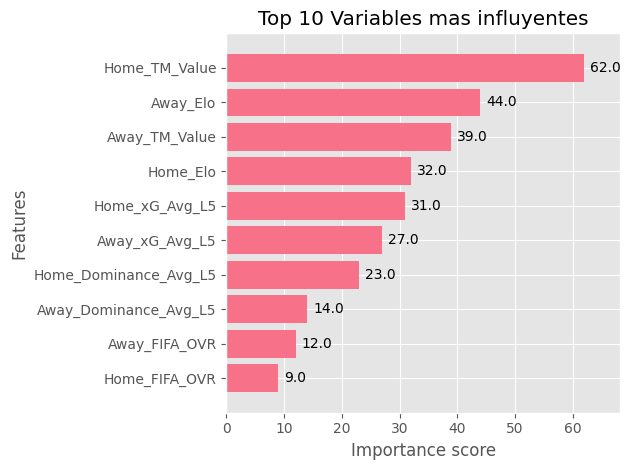

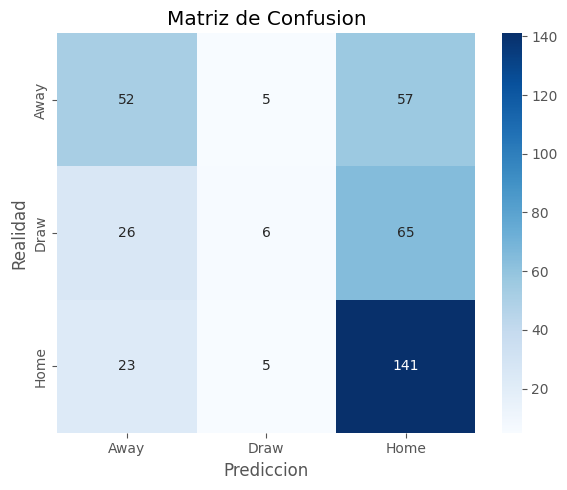

In [74]:
plt.figure(figsize=(10, 6))
xgb.plot_importance(final_model, max_num_features=10, height=0.8, importance_type="weight")
plt.title("Top 10 Variables mas influyentes")
plt.tight_layout()
plt.show()

cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Away", "Draw", "Home"],
            yticklabels=["Away", "Draw", "Home"])
plt.xlabel("Prediccion")
plt.ylabel("Realidad")
plt.title("Matriz de Confusion")
plt.tight_layout()
plt.show()

## 📊 Backtest: Simulación de Apuestas

Validación financiera del modelo mediante simulación retrospectiva:
- **Apuesta plana** (10u por apuesta) vs **Kelly Criterion** (stake proporcional al edge)
- Solo se apuesta cuando **EV > 5%** (margen de seguridad)
- Se utilizan cuotas históricas de Bet365 (`B365H`, `B365D`, `B365A`)

> ⚠️ Este backtest usa el mismo dataset de entrenamiento (in-sample). Para una validación rigurosa out-of-sample, ver Notebook 03.


WALK-FORWARD BACKTEST — 10 Temporadas de Test
Ventana de entrenamiento: 5 años
Temporadas disponibles: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

--- Fold 1: Train [2010, 2011, 2012, 2013, 2014] → Test 2015 (1900 train, 380 test) ---
    Log Loss: 0.9505 | Accuracy: 0.5211
    Apuestas con EV > 5%: 280

--- Fold 2: Train [2011, 2012, 2013, 2014, 2015] → Test 2016 (1900 train, 380 test) ---
    Log Loss: 0.9331 | Accuracy: 0.5737
    Apuestas con EV > 5%: 281

--- Fold 3: Train [2012, 2013, 2014, 2015, 2016] → Test 2017 (1900 train, 380 test) ---
    Log Loss: 0.9823 | Accuracy: 0.5342
    Apuestas con EV > 5%: 303

--- Fold 4: Train [2013, 2014, 2015, 2016, 2017] → Test 2018 (1900 train, 380 test) ---
    Log Loss: 1.0214 | Accuracy: 0.4974
    Apuestas con EV > 5%: 297

--- Fold 5: Train [2014, 2015, 2016, 2017, 2018] → Test 2019 (1900 train, 380 test) ---
    Log Loss: 1.0277 | Accuracy: 0.4711
    Apuestas con EV > 5%: 300

--- Fold 

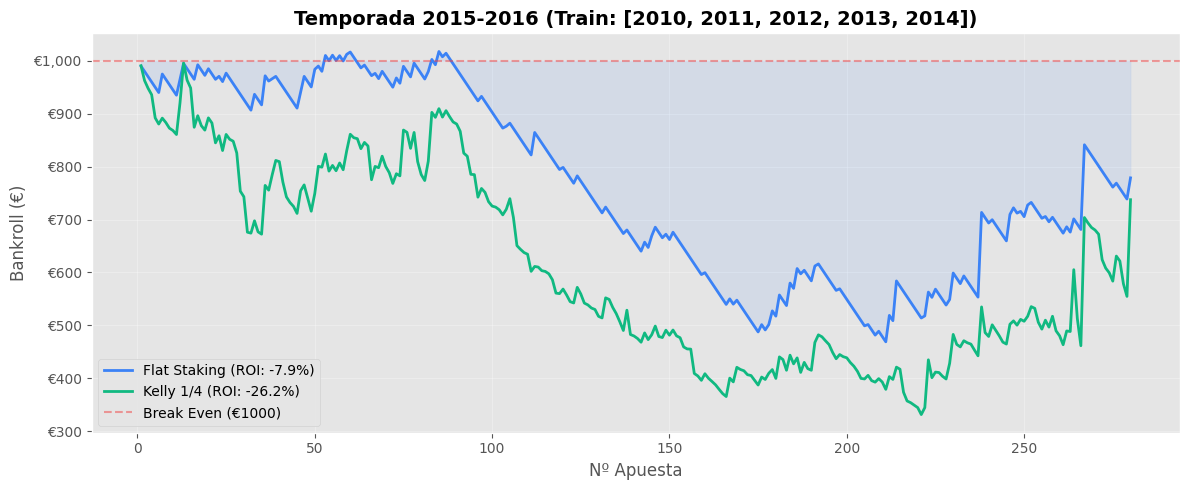


  >>> Detalle de Apuestas (Muestra: 5 primeras + 5 últimas) <<<


date,Match,bet,odds,ev,kelly_stake,Result,Profit
2015-08-22 00:00:00,RCD Espanyol vs Getafe CF,A,4.33,12.5%,€9.35,LOSS,€-9.35
2015-08-22 00:00:00,Rayo Vallecano vs Valencia CF,A,2.05,11.8%,€27.93,LOSS,€-27.93
2015-08-23 00:00:00,Athletic Club vs FC Barcelona,H,6.50,33.6%,€14.70,LOSS,€-14.70
2015-08-23 00:00:00,Real Betis vs Villarreal CF,H,2.80,9.2%,€12.08,LOSS,€-12.08
2015-08-23 00:00:00,Levante UD vs Celta Vigo,H,3.60,48.7%,€43.81,LOSS,€-43.81
2016-05-14 00:00:00,Ath Madrid vs Celta Vigo,H,1.75,32.4%,€63.12,WIN,€47.34
2016-05-15 00:00:00,RCD Espanyol vs Eibar,A,3.70,16.2%,€9.48,LOSS,€-9.48
2016-05-15 00:00:00,Sporting Gijon vs Villarreal CF,A,7.50,179.5%,€42.91,LOSS,€-42.91
2016-05-15 00:00:00,Rayo Vallecano vs Levante UD,A,9.00,131.7%,€23.81,LOSS,€-23.81
2016-05-15 00:00:00,Real Betis vs Getafe CF,H,5.00,131.7%,€45.67,WIN,€182.69



────────────────────────────────────────────────────────────
TEMPORADA 2016-2017
Entrenado con: [2011, 2012, 2013, 2014, 2015]
────────────────────────────────────────────────────────────
  Apuestas: 281  |  Aciertos: 77 (27.4%)
  ROI Flat: -2.44%  |  Bankroll: €932
  ROI Kelly: -35.07%  |  Bankroll: €649

  Desglose por tipo de apuesta:
  Tipo     N  Wins    Hit%     ROI%
     A    96    13   13.5%    -8.5%
     D    22     5   22.7%   -25.7%
     H   163    59   36.2%    +4.3%


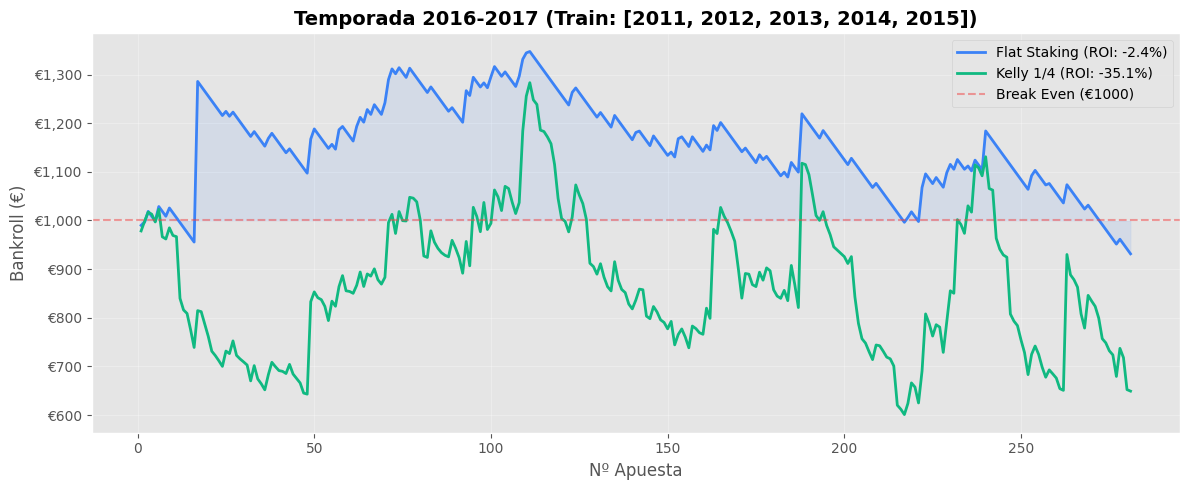


  >>> Detalle de Apuestas (Muestra: 5 primeras + 5 últimas) <<<


date,Match,bet,odds,ev,kelly_stake,Result,Profit
2016-08-19 00:00:00,Malaga vs CA Osasuna,A,6.00,43.0%,€21.49,LOSS,€-21.49
2016-08-20 00:00:00,Sevilla FC vs RCD Espanyol,H,1.67,8.2%,€30.09,WIN,€20.16
2016-08-20 00:00:00,Granada CF vs Villarreal CF,D,3.20,7.4%,€8.42,WIN,€18.52
2016-08-20 00:00:00,FC Barcelona vs Real Betis,A,29.00,46.8%,€4.25,LOSS,€-4.25
2016-08-21 00:00:00,Real Sociedad vs Real Madrid,H,4.75,23.6%,€15.96,LOSS,€-15.96
2017-05-21 00:00:00,Celta Vigo vs Real Sociedad,H,4.75,91.6%,€44.22,LOSS,€-44.22
2017-05-21 00:00:00,Ath Madrid vs Athletic Club,H,2.00,34.0%,€57.70,WIN,€57.70
2017-05-21 00:00:00,Malaga vs Real Madrid,H,11.00,103.2%,€19.03,LOSS,€-19.03
2017-05-21 00:00:00,Valencia CF vs Villarreal CF,H,3.10,76.9%,€65.75,LOSS,€-65.75
2017-05-21 00:00:00,FC Barcelona vs Eibar,A,34.00,63.0%,€3.12,LOSS,€-3.12



────────────────────────────────────────────────────────────
TEMPORADA 2017-2018
Entrenado con: [2012, 2013, 2014, 2015, 2016]
────────────────────────────────────────────────────────────
  Apuestas: 303  |  Aciertos: 100 (33.0%)
  ROI Flat: -4.83%  |  Bankroll: €854
  ROI Kelly: -26.50%  |  Bankroll: €735

  Desglose por tipo de apuesta:
  Tipo     N  Wins    Hit%     ROI%
     A   105    29   27.6%    -8.0%
     D    40     9   22.5%    +6.8%
     H   158    62   39.2%    -5.7%


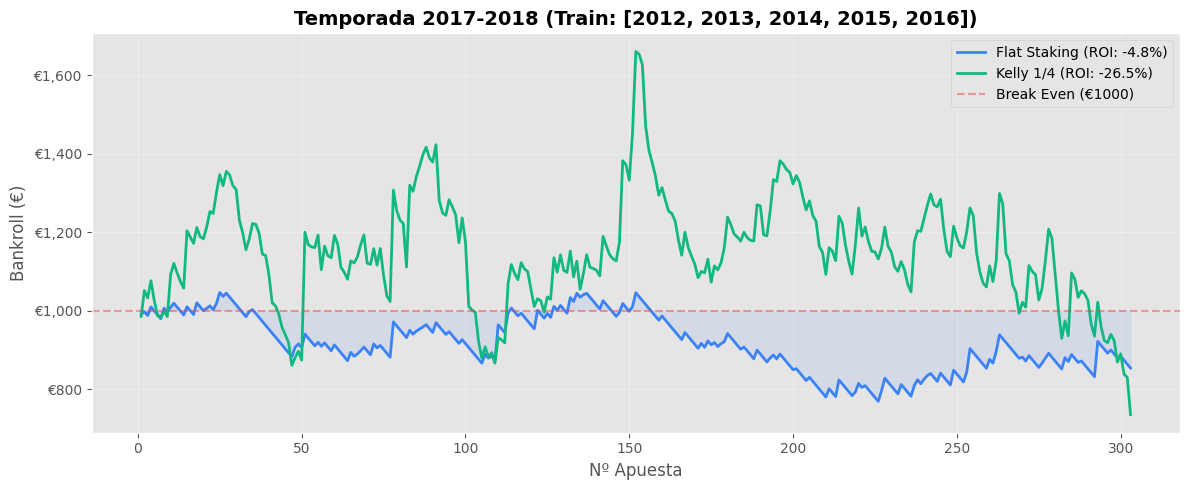


  >>> Detalle de Apuestas (Muestra: 5 primeras + 5 últimas) <<<


date,Match,bet,odds,ev,kelly_stake,Result,Profit
2017-08-18 00:00:00,CD Leganes vs Alaves,A,4.10,18.2%,€14.69,LOSS,€-14.69
2017-08-18 00:00:00,Valencia CF vs UD Las Palmas,H,1.75,26.7%,€87.70,WIN,€65.77
2017-08-19 00:00:00,Girona FC vs Ath Madrid,H,8.00,49.7%,€18.66,LOSS,€-18.66
2017-08-19 00:00:00,Celta Vigo vs Real Sociedad,A,3.20,17.0%,€19.98,WIN,€43.95
2017-08-19 00:00:00,Sevilla FC vs RCD Espanyol,H,1.62,11.7%,€50.78,LOSS,€-50.78
2018-05-19 00:00:00,UD Las Palmas vs Girona FC,H,3.10,49.9%,€54.83,LOSS,€-54.83
2018-05-20 00:00:00,Valencia CF vs La Coruna,H,1.40,9.7%,€52.67,WIN,€21.07
2018-05-20 00:00:00,Athletic Club vs RCD Espanyol,H,2.04,24.2%,€51.68,LOSS,€-51.68
2018-05-20 00:00:00,FC Barcelona vs Real Sociedad,D,7.00,23.8%,€8.32,LOSS,€-8.32
2018-05-20 00:00:00,Ath Madrid vs Eibar,H,1.61,27.9%,€94.91,LOSS,€-94.91



────────────────────────────────────────────────────────────
TEMPORADA 2018-2019
Entrenado con: [2013, 2014, 2015, 2016, 2017]
────────────────────────────────────────────────────────────
  Apuestas: 297  |  Aciertos: 97 (32.7%)
  ROI Flat: +7.31%  |  Bankroll: €1217
  ROI Kelly: +2.68%  |  Bankroll: €1027

  Desglose por tipo de apuesta:
  Tipo     N  Wins    Hit%     ROI%
     A   118    29   24.6%    +7.6%
     D    13     2   15.4%   +10.0%
     H   166    66   39.8%    +6.9%


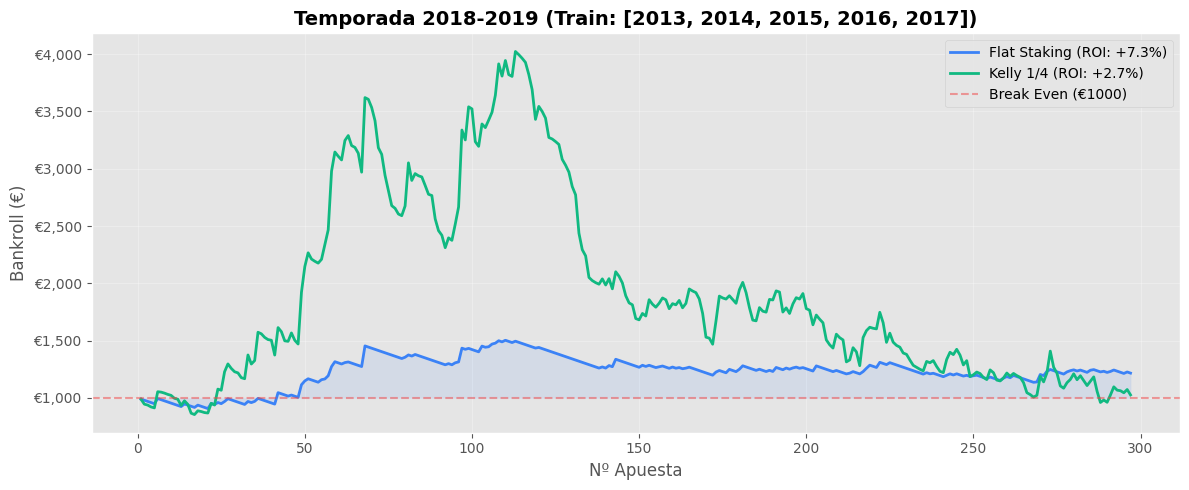


  >>> Detalle de Apuestas (Muestra: 5 primeras + 5 últimas) <<<


date,Match,bet,odds,ev,kelly_stake,Result,Profit
2018-08-17 00:00:00,Girona FC vs Real Valladolid CF,A,5.00,17.4%,€10.90,LOSS,€-10.90
2018-08-17 00:00:00,Real Betis vs Levante UD,H,1.66,11.5%,€43.05,LOSS,€-43.05
2018-08-18 00:00:00,Celta Vigo vs RCD Espanyol,A,4.50,11.8%,€7.96,LOSS,€-7.96
2018-08-18 00:00:00,Villarreal CF vs Real Sociedad,H,2.04,7.3%,€16.42,LOSS,€-16.42
2018-08-18 00:00:00,FC Barcelona vs Alaves,A,21.00,71.0%,€8.17,LOSS,€-8.17
2019-05-18 00:00:00,Levante UD vs Ath Madrid,A,1.95,10.0%,€29.01,LOSS,€-29.01
2019-05-18 00:00:00,Celta Vigo vs Rayo Vallecano,A,7.00,11.2%,€4.99,LOSS,€-4.99
2019-05-18 00:00:00,Getafe CF vs Villarreal CF,A,5.25,28.5%,€17.84,LOSS,€-17.84
2019-05-18 00:00:00,RCD Espanyol vs Real Sociedad,H,2.30,10.8%,€21.66,WIN,€28.16
2019-05-19 00:00:00,Eibar vs FC Barcelona,A,1.90,15.7%,€46.70,LOSS,€-46.70



────────────────────────────────────────────────────────────
TEMPORADA 2019-2020
Entrenado con: [2014, 2015, 2016, 2017, 2018]
────────────────────────────────────────────────────────────
  Apuestas: 300  |  Aciertos: 82 (27.3%)
  ROI Flat: -13.43%  |  Bankroll: €597
  ROI Kelly: -87.51%  |  Bankroll: €125

  Desglose por tipo de apuesta:
  Tipo     N  Wins    Hit%     ROI%
     A    98    19   19.4%   -27.4%
     D    33     9   27.3%    +7.6%
     H   169    54   32.0%    -9.5%


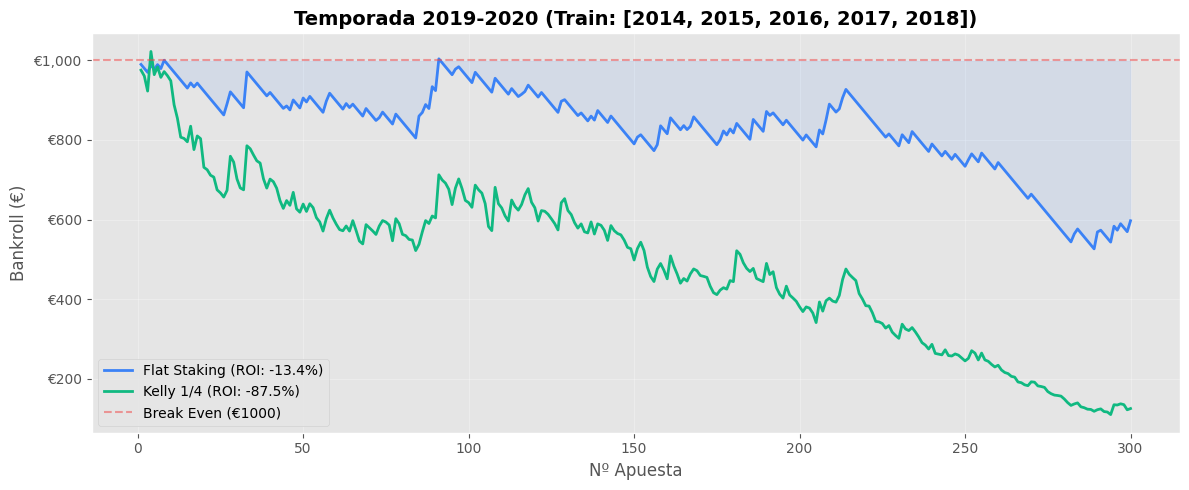


  >>> Detalle de Apuestas (Muestra: 5 primeras + 5 últimas) <<<


date,Match,bet,odds,ev,kelly_stake,Result,Profit
2019-08-16 00:00:00,Athletic Club vs FC Barcelona,D,3.80,27.3%,€24.40,LOSS,€-24.40
2019-08-17 00:00:00,CD Leganes vs CA Osasuna,H,2.00,6.0%,€14.71,LOSS,€-14.71
2019-08-17 00:00:00,Celta Vigo vs Real Madrid,H,4.75,59.2%,€37.92,LOSS,€-37.92
2019-08-17 00:00:00,RCD Mallorca vs Eibar,H,2.80,43.1%,€55.30,WIN,€99.53
2019-08-18 00:00:00,RCD Espanyol vs Sevilla FC,H,3.20,50.1%,€58.23,LOSS,€-58.23
2020-07-19 00:00:00,Villarreal CF vs Eibar,A,6.00,9.9%,€0.66,LOSS,€-0.66
2020-07-19 00:00:00,Real Valladolid CF vs Real Betis,H,2.62,9.1%,€1.88,WIN,€3.04
2020-07-19 00:00:00,Alaves vs FC Barcelona,H,5.50,28.4%,€2.16,LOSS,€-2.16
2020-07-19 00:00:00,RCD Espanyol vs Celta Vigo,H,5.00,153.0%,€12.88,LOSS,€-12.88
2020-07-19 00:00:00,CA Osasuna vs RCD Mallorca,D,3.75,10.3%,€1.14,WIN,€3.13



────────────────────────────────────────────────────────────
TEMPORADA 2020-2021
Entrenado con: [2015, 2016, 2017, 2018, 2019]
────────────────────────────────────────────────────────────
  Apuestas: 280  |  Aciertos: 84 (30.0%)
  ROI Flat: +1.64%  |  Bankroll: €1046
  ROI Kelly: -23.14%  |  Bankroll: €769

  Desglose por tipo de apuesta:
  Tipo     N  Wins    Hit%     ROI%
     A    56    12   21.4%   +47.2%
     D    52    14   26.9%    +8.4%
     H   172    58   33.7%   -15.2%


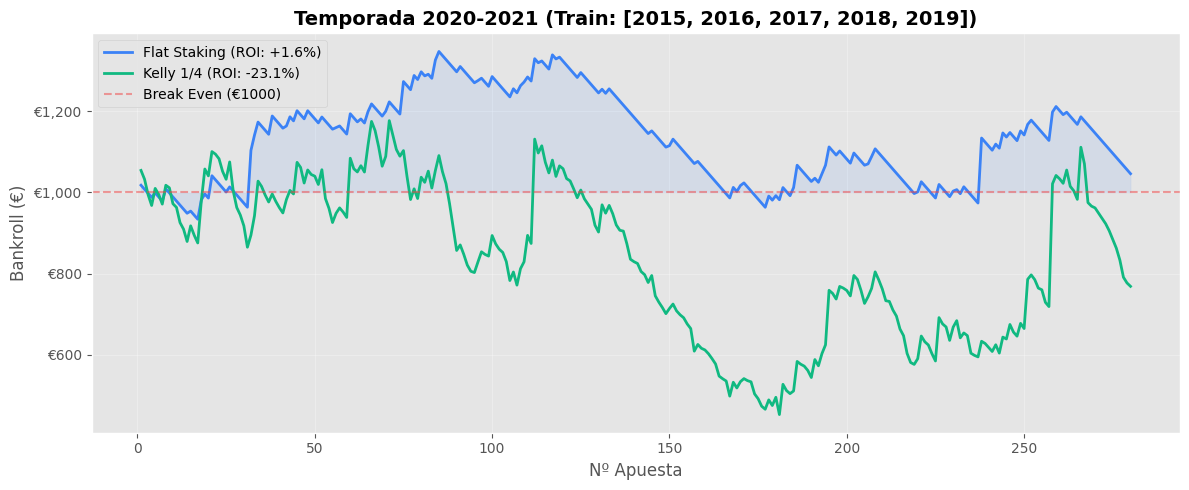


  >>> Detalle de Apuestas (Muestra: 5 primeras + 5 últimas) <<<


date,Match,bet,odds,ev,kelly_stake,Result,Profit
2020-09-12 00:00:00,Granada CF vs Athletic Club,H,2.75,21.6%,€30.79,WIN,€53.88
2020-09-12 00:00:00,Cadiz CF vs CA Osasuna,D,3.00,16.5%,€21.74,LOSS,€-21.74
2020-09-13 00:00:00,Alaves vs Real Betis,D,3.20,32.4%,€38.04,LOSS,€-38.04
2020-09-13 00:00:00,Real Valladolid CF vs Real Sociedad,A,2.60,17.0%,€26.48,LOSS,€-26.48
2020-09-13 00:00:00,Valencia CF vs Levante UD,H,2.10,17.4%,€38.23,WIN,€42.05
2021-05-22 00:00:00,Real Valladolid CF vs Ath Madrid,H,9.00,77.7%,€21.46,LOSS,€-21.46
2021-05-22 00:00:00,Huesca vs Valencia CF,A,5.00,54.6%,€29.45,LOSS,€-29.45
2021-05-22 00:00:00,Celta Vigo vs Real Betis,H,3.20,44.4%,€42.01,LOSS,€-42.01
2021-05-23 00:00:00,Granada CF vs Getafe CF,H,2.62,11.5%,€14.01,LOSS,€-14.01
2021-05-23 00:00:00,Sevilla FC vs Alaves,D,4.33,14.4%,€8.40,LOSS,€-8.40



────────────────────────────────────────────────────────────
TEMPORADA 2021-2022
Entrenado con: [2016, 2017, 2018, 2019, 2020]
────────────────────────────────────────────────────────────
  Apuestas: 268  |  Aciertos: 84 (31.3%)
  ROI Flat: -7.87%  |  Bankroll: €789
  ROI Kelly: -52.62%  |  Bankroll: €474

  Desglose por tipo de apuesta:
  Tipo     N  Wins    Hit%     ROI%
     A   100    28   28.0%    -2.4%
     D    48    11   22.9%    -9.9%
     H   120    45   37.5%   -11.7%


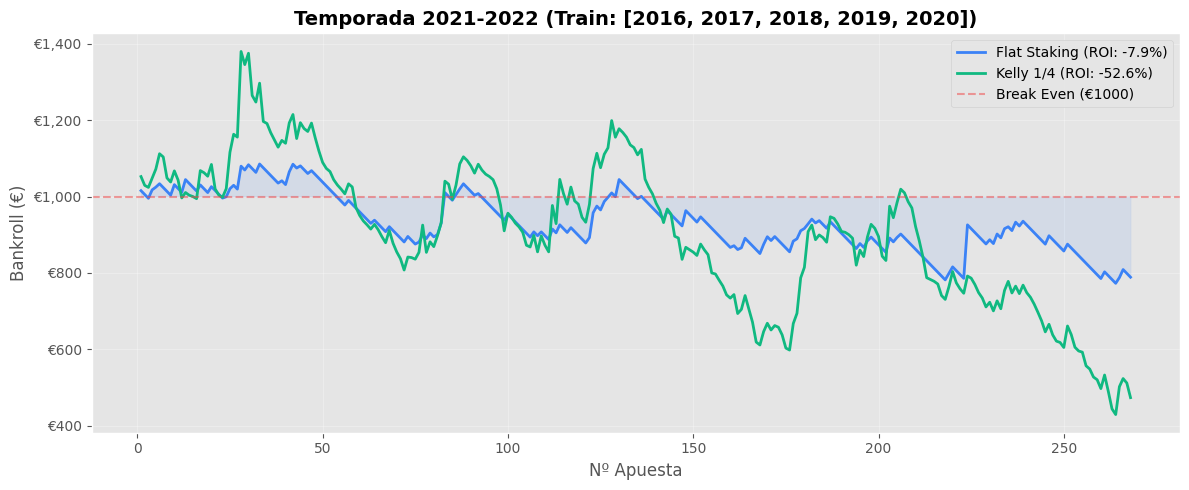


  >>> Detalle de Apuestas (Muestra: 5 primeras + 5 últimas) <<<


date,Match,bet,odds,ev,kelly_stake,Result,Profit
2021-08-13 00:00:00,Valencia CF vs Getafe CF,H,2.55,20.9%,€33.77,WIN,€52.35
2021-08-14 00:00:00,RCD Mallorca vs Real Betis,H,3.30,20.1%,€22.98,LOSS,€-22.98
2021-08-14 00:00:00,Alaves vs Real Madrid,H,7.00,12.4%,€5.31,LOSS,€-5.31
2021-08-14 00:00:00,CA Osasuna vs RCD Espanyol,D,3.20,9.2%,€10.76,WIN,€23.68
2021-08-15 00:00:00,FC Barcelona vs Real Sociedad,H,1.72,9.2%,€33.55,WIN,€24.16
2022-05-22 00:00:00,Granada CF vs RCD Espanyol,A,7.50,88.1%,€15.05,LOSS,€-15.05
2022-05-22 00:00:00,Sevilla FC vs Athletic Club,H,2.50,68.0%,€48.67,WIN,€73.01
2022-05-22 00:00:00,Elche CF vs Getafe CF,H,3.10,16.9%,€10.10,WIN,€21.22
2022-05-22 00:00:00,Real Sociedad vs Ath Madrid,D,3.30,20.4%,€11.60,LOSS,€-11.60
2022-05-22 00:00:00,CA Osasuna vs RCD Mallorca,H,3.30,68.8%,€38.32,LOSS,€-38.32



────────────────────────────────────────────────────────────
TEMPORADA 2022-2023
Entrenado con: [2017, 2018, 2019, 2020, 2021]
────────────────────────────────────────────────────────────
  Apuestas: 254  |  Aciertos: 81 (31.9%)
  ROI Flat: +6.31%  |  Bankroll: €1160
  ROI Kelly: +42.92%  |  Bankroll: €1429

  Desglose por tipo de apuesta:
  Tipo     N  Wins    Hit%     ROI%
     A    72    20   27.8%    +2.6%
     D    70    16   22.9%    -0.5%
     H   112    45   40.2%   +13.0%


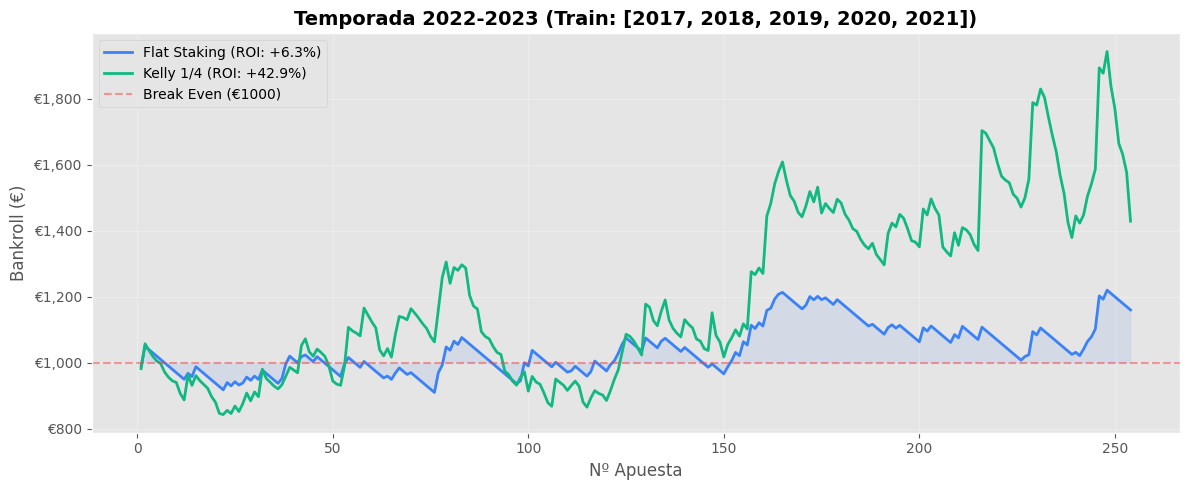


  >>> Detalle de Apuestas (Muestra: 5 primeras + 5 últimas) <<<


date,Match,bet,odds,ev,kelly_stake,Result,Profit
2022-08-13 00:00:00,Real Valladolid CF vs Villarreal CF,H,3.90,20.8%,€17.96,LOSS,€-17.96
2022-08-13 00:00:00,FC Barcelona vs Rayo Vallecano,D,7.00,30.8%,€12.60,WIN,€75.58
2022-08-14 00:00:00,Cadiz CF vs Real Sociedad,H,3.60,19.5%,€19.79,LOSS,€-19.79
2022-08-14 00:00:00,UD Almeria vs Real Madrid,H,7.50,46.1%,€18.39,LOSS,€-18.39
2022-08-15 00:00:00,Real Betis vs Elche CF,A,7.00,33.2%,€14.12,LOSS,€-14.12
2023-06-04 00:00:00,Elche CF vs Cadiz CF,H,2.63,24.1%,€67.92,LOSS,€-67.92
2023-06-04 00:00:00,Celta Vigo vs FC Barcelona,A,2.50,35.6%,€105.08,LOSS,€-105.08
2023-06-04 00:00:00,Villarreal CF vs Ath Madrid,A,2.50,12.0%,€33.33,LOSS,€-33.33
2023-06-04 00:00:00,RCD Espanyol vs UD Almeria,H,2.75,23.3%,€54.35,LOSS,€-54.35
2023-06-04 00:00:00,Real Madrid vs Athletic Club,H,1.91,34.2%,€148.13,LOSS,€-148.13



────────────────────────────────────────────────────────────
TEMPORADA 2023-2024
Entrenado con: [2018, 2019, 2020, 2021, 2022]
────────────────────────────────────────────────────────────
  Apuestas: 271  |  Aciertos: 78 (28.8%)
  ROI Flat: -15.34%  |  Bankroll: €584
  ROI Kelly: -77.33%  |  Bankroll: €227

  Desglose por tipo de apuesta:
  Tipo     N  Wins    Hit%     ROI%
     A    85    19   22.4%   -32.0%
     D    83    23   27.7%    +6.1%
     H   103    36   35.0%   -18.9%


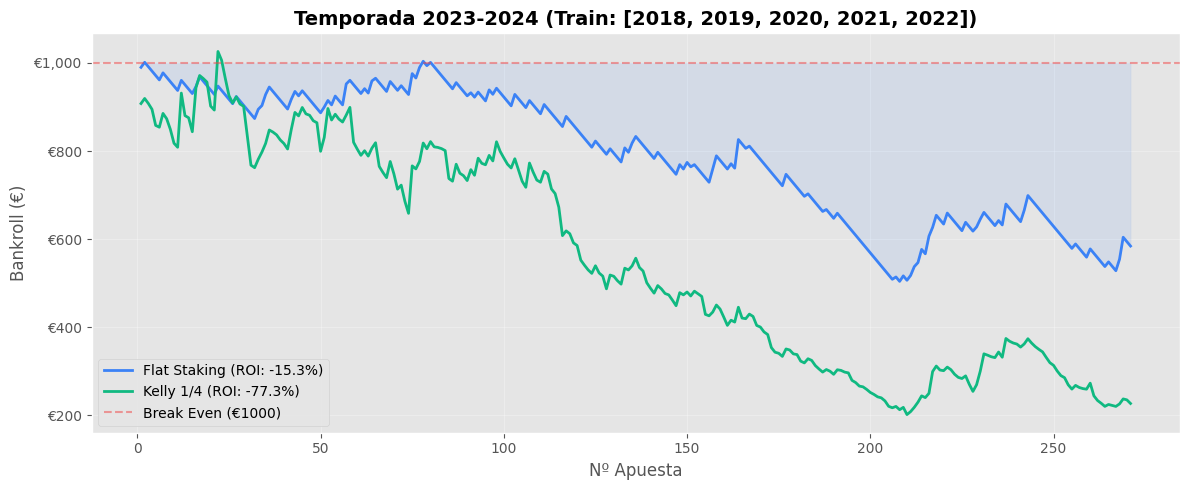


  >>> Detalle de Apuestas (Muestra: 5 primeras + 5 últimas) <<<


date,Match,bet,odds,ev,kelly_stake,Result,Profit
2023-08-12 00:00:00,UD Las Palmas vs RCD Mallorca,H,2.40,51.6%,€92.20,LOSS,€-92.20
2023-08-12 00:00:00,Athletic Club vs Real Madrid,A,2.15,5.1%,€10.02,WIN,€11.52
2023-08-13 00:00:00,Villarreal CF vs Real Betis,D,4.00,14.7%,€11.27,LOSS,€-11.27
2023-08-13 00:00:00,Getafe CF vs FC Barcelona,H,6.50,32.3%,€13.34,LOSS,€-13.34
2023-08-14 00:00:00,Cadiz CF vs Alaves,A,3.75,44.9%,€36.52,LOSS,€-36.52
2024-05-25 00:00:00,Real Sociedad vs Ath Madrid,D,3.30,9.1%,€2.20,LOSS,€-2.20
2024-05-25 00:00:00,CA Osasuna vs Villarreal CF,D,3.60,10.3%,€2.18,WIN,€5.66
2024-05-25 00:00:00,Real Madrid vs Real Betis,D,6.00,20.1%,€2.27,WIN,€11.35
2024-05-26 00:00:00,UD Las Palmas vs Alaves,A,3.00,7.1%,€2.12,LOSS,€-2.12
2024-05-26 00:00:00,Getafe CF vs RCD Mallorca,H,2.30,18.3%,€8.26,LOSS,€-8.26



────────────────────────────────────────────────────────────
TEMPORADA 2024-2025
Entrenado con: [2019, 2020, 2021, 2022, 2023]
────────────────────────────────────────────────────────────
  Apuestas: 292  |  Aciertos: 81 (27.7%)
  ROI Flat: -9.97%  |  Bankroll: €709
  ROI Kelly: -66.38%  |  Bankroll: €336

  Desglose por tipo de apuesta:
  Tipo     N  Wins    Hit%     ROI%
     A   104    25   24.0%   -17.7%
     D    74    15   20.3%   -23.6%
     H   114    41   36.0%    +6.0%


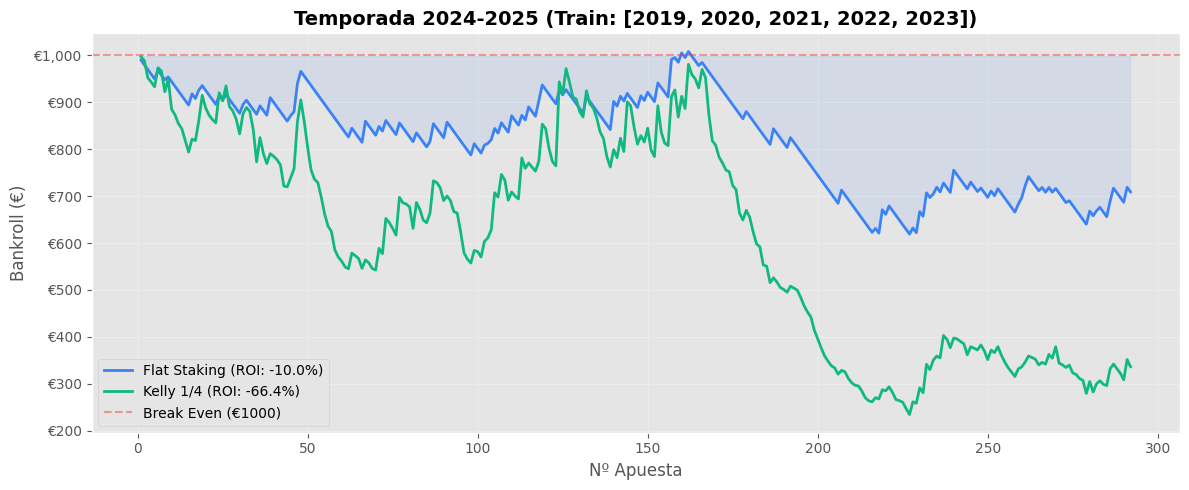


  >>> Detalle de Apuestas (Muestra: 5 primeras + 5 últimas) <<<


date,Match,bet,odds,ev,kelly_stake,Result,Profit
2024-08-15 00:00:00,Athletic Club vs Getafe CF,A,8.00,7.5%,€2.66,LOSS,€-2.66
2024-08-16 00:00:00,Celta Vigo vs Alaves,A,4.10,10.7%,€8.64,LOSS,€-8.64
2024-08-16 00:00:00,UD Las Palmas vs Sevilla FC,H,2.80,26.3%,€36.16,LOSS,€-36.16
2024-08-17 00:00:00,CA Osasuna vs CD Leganes,A,4.50,13.6%,€9.24,LOSS,€-9.24
2024-08-18 00:00:00,RCD Mallorca vs Real Madrid,H,8.00,29.7%,€10.02,LOSS,€-10.02
2025-05-24 00:00:00,Getafe CF vs Celta Vigo,H,4.10,35.3%,€9.73,LOSS,€-9.73
2025-05-24 00:00:00,RCD Espanyol vs UD Las Palmas,A,8.00,81.8%,€9.70,LOSS,€-9.70
2025-05-24 00:00:00,CD Leganes vs Real Valladolid CF,A,9.50,148.6%,€14.09,LOSS,€-14.09
2025-05-24 00:00:00,Rayo Vallecano vs RCD Mallorca,D,4.20,56.1%,€13.51,WIN,€43.24
2025-05-25 00:00:00,Athletic Club vs FC Barcelona,H,3.20,38.3%,€15.28,LOSS,€-15.28



RESUMEN GLOBAL — TODAS LAS TEMPORADAS


,bets,wins,hit_rate,flat_roi,flat_final,kelly_roi,kelly_final
season,,,,,,,
2015,280,80,28.6,-7.90,779.0,-26.25,738.0
2016,281,77,27.4,-2.44,932.0,-35.07,649.0
2017,303,100,33.0,-4.83,854.0,-26.50,735.0
2018,297,97,32.7,7.31,1217.0,2.68,1027.0
2019,300,82,27.3,-13.43,597.0,-87.51,125.0
2020,280,84,30.0,1.64,1046.0,-23.14,769.0
2021,268,84,31.3,-7.87,789.0,-52.62,474.0
2022,254,81,31.9,6.31,1160.0,42.92,1429.0
2023,271,78,28.8,-15.34,584.0,-77.33,227.0



Media ROI Flat: -4.65%
Total apuestas: 2826
Total aciertos: 844 (29.9%)


In [75]:
# ============================================================
# BACKTEST: Walk-Forward por Temporadas con Apuestas Combinadas
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import log_loss, accuracy_score

# --- Configuración ---
INITIAL_BANKROLL = 1000
FLAT_STAKE = 10
MIN_EV = 0.05        # Solo apostar si EV > 5%
KELLY_FRACTION = 0.25 # Cuarto Kelly (más conservador)
WINDOW_SIZE = 5       # Años de entrenamiento

# --- Preparar datos ---
df_bt = df.copy()

# DEDUPLICAR: Season 2024 contiene filas duplicadas (3040 vs 380 esperadas)
# Identificamos duplicados por Date + HomeTeam + AwayTeam y nos quedamos con el primero
before = len(df_bt)
df_bt = df_bt.drop_duplicates(subset=['Date', 'HomeTeam', 'AwayTeam'], keep='first')
after = len(df_bt)
if before != after:
    print(f"⚠️ Se eliminaron {before - after} filas duplicadas ({before} → {after})")

odds_cols = ['B365H', 'B365D', 'B365A']

# Verificar que las cuotas existen
has_odds = all(c in df_bt.columns for c in odds_cols)
if not has_odds:
    print('⚠️ Columnas de cuotas B365 no encontradas. Backtest no disponible.')
else:
    # Eliminar filas sin cuotas
    df_bt = df_bt.dropna(subset=odds_cols + features + ['Target'])
    df_bt = df_bt.sort_values('Date').reset_index(drop=True)
    
    # --- Walk-Forward por Temporadas ---
    seasons_bt = sorted(df_bt['Season'].unique())
    n_folds = len(seasons_bt) - WINDOW_SIZE
    
    print(f"\n{'='*60}")
    print(f"WALK-FORWARD BACKTEST — {n_folds} Temporadas de Test")
    print(f"Ventana de entrenamiento: {WINDOW_SIZE} años")
    print(f"Temporadas disponibles: {seasons_bt}")
    print(f"{'='*60}")
    
    all_season_results = {}  # dict: season -> list of bet results
    
    for fold_i in range(n_folds):
        fold = fold_i + 1
        train_seasons = seasons_bt[fold_i : fold_i + WINDOW_SIZE]
        test_season   = seasons_bt[fold_i + WINDOW_SIZE]
        
        train_mask = df_bt['Season'].isin(train_seasons)
        test_mask  = df_bt['Season'] == test_season
        
        X_train_f = df_bt.loc[train_mask, features].astype(float)
        y_train_f = df_bt.loc[train_mask, 'Target'].astype(int)
        X_test_f  = df_bt.loc[test_mask,  features].astype(float)
        y_test_f  = df_bt.loc[test_mask,  'Target'].astype(int)
        
        n_train = len(X_train_f)
        n_test  = len(X_test_f)
        
        # --- Entrenar modelo ---
        _params = best_params if 'best_params' in dir() else {
            'objective': 'multi:softprob', 'num_class': 3, 'max_depth': 4,
            'learning_rate': 0.05, 'n_estimators': 150, 'random_state': 42
        }
        bt_model = xgb.XGBClassifier(**_params)
        bt_model.fit(X_train_f, y_train_f)
        
        # --- Predecir ---
        proba = bt_model.predict_proba(X_test_f)
        preds = bt_model.predict(X_test_f)
        ll = log_loss(y_test_f, proba)
        acc = accuracy_score(y_test_f, preds)
        
        print(f"\n--- Fold {fold}: Train {train_seasons} → Test {int(test_season)} "
              f"({n_train} train, {n_test} test) ---")
        print(f"    Log Loss: {ll:.4f} | Accuracy: {acc:.4f}")
        
        # --- Evaluar apuestas ---
        test_indices = df_bt.index[test_mask].tolist()
        season_results = []
        
        for j, idx in enumerate(test_indices):
            row = df_bt.iloc[idx]
            p_A, p_D, p_H = proba[j]  # Mapping: A=0, D=1, H=2
            
            odds_H = row['B365H']
            odds_D = row['B365D']
            odds_A = row['B365A']
            actual = int(row['Target'])  # 0=A, 1=D, 2=H
            
            # === APUESTAS SIMPLES ===
            bets = []
            # Home win
            bets.append(('H', p_H, odds_H, actual == 2))
            # Draw
            bets.append(('D', p_D, odds_D, actual == 1))
            # Away win
            bets.append(('A', p_A, odds_A, actual == 0))
            
            # === APUESTAS COMBINADAS (Doble Oportunidad) ===
            # 1X = Home o Draw
            p_1X = p_H + p_D
            odds_1X = 1.0 / (1.0/odds_H + 1.0/odds_D)
            bets.append(('1X', p_1X, odds_1X, actual in (1, 2)))
            
            # X2 = Draw o Away
            p_X2 = p_D + p_A
            odds_X2 = 1.0 / (1.0/odds_D + 1.0/odds_A)
            bets.append(('X2', p_X2, odds_X2, actual in (0, 1)))
            
            # 12 = Home o Away
            p_12 = p_H + p_A
            odds_12 = 1.0 / (1.0/odds_H + 1.0/odds_A)
            bets.append(('12', p_12, odds_12, actual in (0, 2)))
            
            # --- Calcular EV y elegir la mejor ---
            best_bet = None
            best_ev_val = -999
            for (bet_name, prob, odds_val, won) in bets:
                ev = (prob * odds_val) - 1
                if ev > best_ev_val:
                    best_ev_val = ev
                    best_bet = (bet_name, prob, odds_val, won, ev)
            
            if best_bet is not None and best_ev_val > MIN_EV:
                bet_name, prob, odds_val, won, ev = best_bet
                kelly = max(0, (prob * odds_val - 1) / (odds_val - 1)) * KELLY_FRACTION
                
                season_results.append({
                    'date': row['Date'],
                    'home': row.get('HomeTeam', ''),
                    'away': row.get('AwayTeam', ''),
                    'bet': bet_name,
                    'odds': odds_val,
                    'prob': prob,
                    'ev': ev,
                    'won': won,
                    'kelly_pct': kelly,
                    'fold': fold
                })
        
        all_season_results[int(test_season)] = season_results
        print(f"    Apuestas con EV > {MIN_EV*100:.0f}%: {len(season_results)}")

    # ================================================================
    # GRÁFICAS POR TEMPORADA
    # ================================================================
    print(f"\n{'='*60}")
    print("RESULTADOS POR TEMPORADA")
    print(f"{'='*60}")
    
    global_summary = []
    
    for season_year in sorted(all_season_results.keys()):
        results = all_season_results[season_year]
        if not results:
            print(f"\nTemporada {season_year}: Sin apuestas con EV > {MIN_EV*100:.0f}%")
            continue
        
        df_res = pd.DataFrame(results)
        df_res['date'] = pd.to_datetime(df_res['date'])
        df_res = df_res.sort_values('date').reset_index(drop=True)
        
        # Flat staking P&L
        df_res['flat_pnl'] = df_res.apply(
            lambda r: FLAT_STAKE * (r['odds'] - 1) if r['won'] else -FLAT_STAKE, axis=1
        )
        df_res['flat_cumsum'] = INITIAL_BANKROLL + df_res['flat_pnl'].cumsum()
        
        # Kelly P&L
        kelly_bank = INITIAL_BANKROLL
        kelly_curve = []
        kelly_stakes = []
        
        for _, r in df_res.iterrows():
            stake = kelly_bank * r['kelly_pct']
            kelly_stakes.append(stake)
            if r['won']:
                kelly_bank += stake * (r['odds'] - 1)
            else:
                kelly_bank -= stake
            kelly_curve.append(kelly_bank)
        
        df_res['kelly_cumsum'] = kelly_curve
        df_res['kelly_stake'] = kelly_stakes
        
        # --- Métricas ---
        total_bets = len(df_res)
        wins = int(df_res['won'].sum())
        hit_rate = wins / total_bets * 100
        flat_roi = df_res['flat_pnl'].sum() / (total_bets * FLAT_STAKE) * 100
        kelly_roi = (kelly_bank - INITIAL_BANKROLL) / INITIAL_BANKROLL * 100
        flat_final = df_res['flat_cumsum'].iloc[-1]
        
        # Desglose por tipo de apuesta
        bet_breakdown = df_res.groupby('bet').agg(
            n=('won', 'count'),
            wins=('won', 'sum'),
            pnl=('flat_pnl', 'sum')
        )
        bet_breakdown['hit'] = (bet_breakdown['wins'] / bet_breakdown['n'] * 100).round(1)
        bet_breakdown['roi'] = (bet_breakdown['pnl'] / (bet_breakdown['n'] * FLAT_STAKE) * 100).round(1)
        
        # Temporadas de entrenamiento usadas
        fold_idx = season_year - seasons_bt[WINDOW_SIZE]
        train_used = seasons_bt[fold_idx : fold_idx + WINDOW_SIZE]
        
        print(f"\n{'─'*60}")
        print(f"TEMPORADA {season_year}-{season_year+1}")
        print(f"Entrenado con: {list(map(int, train_used))}")
        print(f"{'─'*60}")
        print(f"  Apuestas: {total_bets}  |  Aciertos: {wins} ({hit_rate:.1f}%)")
        print(f"  ROI Flat: {flat_roi:+.2f}%  |  Bankroll: €{flat_final:.0f}")
        print(f"  ROI Kelly: {kelly_roi:+.2f}%  |  Bankroll: €{kelly_bank:.0f}")
        print(f"\n  Desglose por tipo de apuesta:")
        print(f"  {'Tipo':>4s}  {'N':>4s}  {'Wins':>4s}  {'Hit%':>6s}  {'ROI%':>7s}")
        for bt_name, bt_row in bet_breakdown.iterrows():
            print(f"  {bt_name:>4s}  {int(bt_row['n']):>4d}  {int(bt_row['wins']):>4d}  "
                  f"{bt_row['hit']:>5.1f}%  {bt_row['roi']:>+6.1f}%")
        
        global_summary.append({
            'season': f"{season_year}",
            'bets': total_bets,
            'wins': wins,
            'hit_rate': round(hit_rate, 1),
            'flat_roi': round(flat_roi, 2),
            'flat_final': round(flat_final, 0),
            'kelly_roi': round(kelly_roi, 2),
            'kelly_final': round(kelly_bank, 0)
        })
        
        # === GRÁFICA POR TEMPORADA ===
        fig, ax = plt.subplots(figsize=(12, 5))
        
        bet_numbers = range(1, total_bets + 1)
        
        ax.plot(bet_numbers, df_res['flat_cumsum'], 
                label=f'Flat Staking (ROI: {flat_roi:+.1f}%)', 
                color='#3b82f6', linewidth=2)
        ax.plot(bet_numbers, df_res['kelly_cumsum'], 
                label=f'Kelly 1/4 (ROI: {kelly_roi:+.1f}%)', 
                color='#10b981', linewidth=2)
        ax.axhline(y=INITIAL_BANKROLL, color='#ef4444', linestyle='--', 
                   alpha=0.5, label='Break Even (€1000)')
        ax.fill_between(bet_numbers, INITIAL_BANKROLL, df_res['flat_cumsum'], 
                        alpha=0.1, color='#3b82f6')
        
        ax.set_title(f'Temporada {season_year}-{season_year+1} '
                     f'(Train: {list(map(int, train_used))})', 
                     fontsize=14, fontweight='bold')
        ax.set_xlabel('Nº Apuesta')
        ax.set_ylabel('Bankroll (€)')
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)
        ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('€{x:,.0f}'))
        plt.tight_layout()
        plt.show()

        # === TABLA DETALLE DE APUESTAS ===
        print(f"\n  >>> Detalle de Apuestas (Muestra: 5 primeras + 5 últimas) <<<")
        df_disp = df_res.copy()
        df_disp['Match'] = df_disp['home'] + ' vs ' + df_disp['away']
        df_disp['Result'] = df_disp['won'].map({True: 'WIN', False: 'LOSS'})
        df_disp['Profit'] = df_disp.apply(lambda r: r['kelly_stake'] * (r['odds'] - 1) if r['won'] else -r['kelly_stake'], axis=1)
        
        cols_show = ['date', 'Match', 'bet', 'odds', 'ev', 'kelly_stake', 'Result', 'Profit']
        
        # Formato para mostrar
        format_dict = {'ev': '{:.1%}', 'kelly_stake': '€{:.2f}', 'Profit': '€{:.2f}', 'odds': '{:.2f}'}
        
        if len(df_disp) > 10:
            df_show = pd.concat([df_disp[cols_show].head(5), df_disp[cols_show].tail(5)])
        else:
            df_show = df_disp[cols_show]
            
        # Check if we are in an IPython environment for display(), else print
        try:
             # Just simple styling if display is available (it is in Jupyter)
             display(df_show.style.format(format_dict).hide(axis='index'))
        except:
             print(df_show.to_string())

    # === TABLA RESUMEN GLOBAL ===
    if global_summary:
        print(f"\n{'='*60}")
        print("RESUMEN GLOBAL — TODAS LAS TEMPORADAS")
        print(f"{'='*60}")
        df_summary = pd.DataFrame(global_summary)
        display(df_summary.set_index('season'))
        
        avg_roi = df_summary['flat_roi'].mean()
        total_bets_all = df_summary['bets'].sum()
        total_wins_all = df_summary['wins'].sum()
        print(f"\nMedia ROI Flat: {avg_roi:+.2f}%")
        print(f"Total apuestas: {total_bets_all}")
        print(f"Total aciertos: {total_wins_all} ({total_wins_all/total_bets_all*100:.1f}%)")


## 📊 Backtest: Simulación de Apuestas

Validación financiera del modelo mediante simulación retrospectiva:
- **Apuesta plana** (10u por apuesta) vs **Kelly Criterion** (stake proporcional al edge)
- Solo se apuesta cuando **EV > 5%** (margen de seguridad)
- Se utilizan cuotas históricas de Bet365 (`B365H`, `B365D`, `B365A`)

> ⚠️ Este backtest usa el mismo dataset de entrenamiento (in-sample). Para una validación rigurosa out-of-sample, ver Notebook 03.

In [76]:
# [CELDA ELIMINADA — Backtest consolidado en celda anterior]
